In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
import os
os.getcwd()

'/Users/sumayyauddin/Documents/Predictive Analytics /Individual Coursework/Data '

In [3]:
os.listdir()

['sales_forecasting.ipynb', 'train.csv', '.ipynb_checkpoints', 'archive.zip']

In [4]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.shape

(9800, 18)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [8]:
df["Order Date"].head()

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[ns]

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

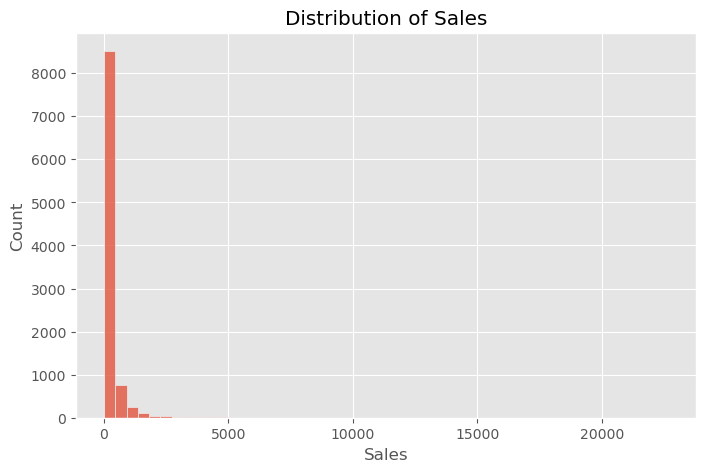

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=50)
plt.title("Distribution of Sales")
plt.show()

### Distribution of Sales

The distribution of sales is strongly right-skewed, with most transactions clustered around relatively low sales values 
and a small number of orders generating exceptionally high sales amounts. This indicates the presence of outliers and 
suggests that model evaluation should take into account the potential for larger prediction errors on high-value transactions.

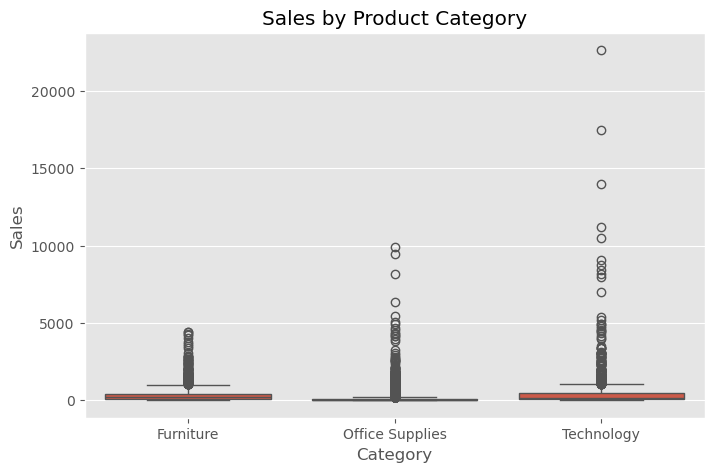

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Sales", data=df)
plt.title("Sales by Product Category")
plt.show()

### Sales by Product Category

The boxplot shows substantial variation in sales across the three product categories, with all categories exhibiting numerous high-value outliers. 
Technology appears to generate the largest extreme transactions, indicating that a relatively small number of technology orders contribute disproportionately to total revenue.
This pattern suggests that product category is likely to be an informative predictor of sales, whilst also highlighting the importance of evaluating model performance carefully in the presence of unusually large orders.

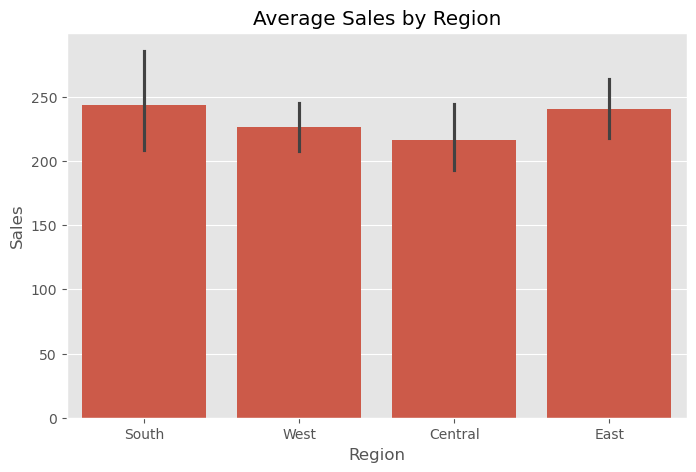

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x="Region", y="Sales", data=df)
plt.title("Average Sales by Region")
plt.show()

### Average Sales by Region

Average sales appear relatively similar across the four regions, although the East and South show slightly higher mean sales than the West and Central regions. 
The differences are not especially large, which suggests that region alone may not be a strong standalone predictor of sales. 
Nevertheless, the presence of some variation indicates that regional information may still contribute useful contextual signal when combined with other product and 
temporal features.


In [ ]:
sales_time = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(12,5))
sales_time.plot()
plt.title("Sales Over Time")
plt.show()

### Sales Over Time

Sales over time exhibit substantial volatility, with frequent short-term fluctuations and several pronounced spikes. 
This pattern suggests that sales are influenced by irregular high-value transactions rather than a smooth and stable trend. 
The time series therefore indicates that temporal features may contain useful predictive information, although the presence of sharp peaks also, implies that forecasting performance should be interpreted carefully in relation to extreme observations.


In [ ]:
df["year"] = df["Order Date"].dt.year
df["month"] = df["Order Date"].dt.month
df["day"] = df["Order Date"].dt.day
df["weekday"] = df["Order Date"].dt.weekday

In [ ]:
df[["Order Date","year","month","weekday"]].head()

In [ ]:
monthly_sales = df.groupby("month")["Sales"].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="bar")
plt.title("Average Sales by Month")
plt.show()

### Average Sales by Month

Average sales vary across months, although the differences are moderate rather than dramatic. 
March appears to record the highest average sales, while February is comparatively lower, which may indicate some limited seasonal variation 
in purchasing behaviour. 
Overall, the pattern suggests that month could provide useful predictive information, but that seasonality in this dataset is present only to 
a modest degree.


In [ ]:
df.dtypes

In [ ]:
df_model = df.drop(columns=[
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "Product ID",
    "Product Name",
    "Order Date",
    "Ship Date",
    "Postal Code"
])

In [ ]:
X = df_model.drop("Sales", axis=1)
y = df_model["Sales"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

In [ ]:
X.isnull().sum().sort_values(ascending=False).head(10)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
print(rmse_lr)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print(rmse_rf)

In [ ]:
print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)

In [ ]:
### Feature Importance

In [ ]:
feature_importance.head(10).plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

### Top 10 Important Features

The feature importance plot highlights the variables that contribute most strongly to the Random Forest model’s predictions. 
Temporal features such as day, month, year, and weekday appear among the most influential predictors, 
indicating that the timing of an order carries meaningful information for sales estimation. 
In addition, specific product sub-categories and location-based features also rank highly, suggesting that sales are shaped by a combination
of temporal, geographic, and product-level characteristics rather than by a single dominant factor.


### Actual versus Predicted Sales

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_lr, alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")

plt.show()

### Actual vs Predicted Sales

The scatter plot compares observed sales values with those predicted by the Linear Regression model. 
Although the model captures the general concentration of lower-value transactions, the points are widely dispersed rather 
than closely aligned,
indicating limited predictive precision. In particular, the model appears to struggle with large sales values, 
suggesting that a simple linear specification may not fully capture the underlying complexity of the dataset.


In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[["Sales","year","month","day","weekday"]].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix

The correlation matrix shows that the engineered temporal variables have only very weak linear relationships with sales. 
This indicates that no individual date-based feature, in isolation, provides a strong linear explanation of sales variation. 
Such a result supports the decision to move beyond simple descriptive analysis 
and evaluate predictive models capable of combining multiple features simultaneously.


In [ ]:
import plotly.express as px

# Create sales by state
state_sales = df.groupby("State")["Sales"].sum().reset_index()

# Dictionary to convert state names to abbreviations
us_state_abbrev = {
'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR',
'California':'CA','Colorado':'CO','Connecticut':'CT','Delaware':'DE',
'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
'Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
'Wisconsin':'WI','Wyoming':'WY'
}

# Convert state names to abbreviations
state_sales["state_code"] = state_sales["State"].map(us_state_abbrev)

In [ ]:
fig = px.choropleth(
    state_sales,
    locations="state_code",
    locationmode="USA-states",
    color="Sales",
    scope="usa",
    color_continuous_scale="Reds",
    title="Total Sales by State"
)

fig.show()

### Geographic Distribution of Sales

The choropleth map indicates that total sales are concentrated in a relatively small number of U.S. states, 
most notably California, New York and Texas. This suggests that demand is uneven across regions, 
with economically larger states contributing disproportionately to overall revenue. 
Geographic variation may therefore serve as an important contextual factor in interpreting sales performance.

## 3. Data Preparation

This stage prepared the dataset for predictive modelling. 
The `Order Date` variable was converted to datetime format and used to engineer four temporal predictors: year, month, day, 
and weekday. Missing values were checked prior to modelling, and `Postal Code` was excluded because it contained a small number 
of missing observations whilst offering limited predictive value in its raw form. 

In addition, non-predictive identifiers such as customer and product IDs were removed to avoid introducing unnecessary noise 
into the models. Categorical variables were then one-hot encoded so that they could be used within scikit-learn regression models.
Finally, the data was split into training and test sets to ensure that model performance could be evaluated on unseen observations.


## 4. Model Development

Two predictive models were explored in this project. Linear Regression was used as the baseline model because it provides a simple
and interpretable benchmark for a continuous prediction task.
                           
Random Forest Regressor was then tested as a more flexible non-linear alternative in order to assess whether a more complex ensemble
method could improve predictive accuracy.

This approach follows the logic of establishing a baseline before comparing alternative models, 
thereby allowing model choice to be justified on the basis of evidence rather than assumption.

### Baseline Model: Linear Regression

Linear Regression was selected as the baseline model because sales is a continuous target variable and the method offers a 
transparent benchmark against which more complex models can be compared. 
The model was trained on the processed training data and evaluated on the held-out test set using Root Mean Squared Error (RMSE).

### Comparison Model: Random Forest Regressor

In [ ]:
Random Forest Regressor was selected as a comparison model because it is capable of capturing non-linear relationships
and interactions between predictors that a simple linear model may fail to detect. This makes it a useful candidate for 
testing whether additional model complexity can improve predictive performance in the presence of heterogeneous sales patterns.

## 5. Model Evaluation

Model performance was evaluated using Root Mean Squared Error (RMSE), 

which is appropriate for regression problems because it measures the average magnitude of prediction errors whilst,
penalising larger errors more heavily. This is particularly relevant in the present dataset, 

where sales values are highly skewed and include a number of unusually large transactions.
The Linear Regression model achieved a lower RMSE than the Random Forest model, 
indicating superior predictive performance on the test data. 

    Although Random Forest offered greater flexibility, 
its higher error suggests that the additional complexity did not translate into improved generalisation for this dataset. 

    This finding reinforces the importance of comparing models empirically rather than assuming that more sophisticated methods 
will necessarily perform better.

## 6. Final Solution and Discussion

Based on the evaluation results, Linear Regression was selected as the final model for this project because it produced the lowest RMSE
on the test set. 
Although Random Forest provided a useful comparison as a non-linear method, it did not improve predictive accuracy in this case. The final results suggest that the available predictors contain some useful signal, but that the dataset remains challenging due to its strong skewness, 
pronounced outliers, and substantial variation across orders.
Several limitations should be acknowledged.
First, the target variable contains a large number of small transactions alongside a small number of very large sales values, 
which makes accurate prediction difficult. 

Secondly, the dataset is limited to the variables available in the original file 
and does not include potentially important external factors such as promotions, macroeconomic conditions, or customer purchasing history. 
Future work could therefore explore alternative feature engineering strategies, 
additional regression models, or transformation of the target variable in order to improve predictive performance.

Overall, the project demonstrates an end-to-end predictive analytics workflow, 
from problem framing and exploratory analysis through to preprocessing, modelling, and evaluation. 
The results also show the value of evidence-based model selection, as the simpler baseline model
ultimately outperformed the more complex alternative.

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Rebuild modelling data just for validation checks
df_check = df.drop(columns=[
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "Product ID",
    "Product Name",
    "Order Date",
    "Ship Date",
    "Postal Code"
])

X_check = df_check.drop("Sales", axis=1)
y_check = df_check["Sales"]

X_check = pd.get_dummies(X_check, drop_first=True)

X_train_check, X_test_check, y_train_check, y_test_check = train_test_split(
    X_check, y_check, test_size=0.2, random_state=42
)

print("X shape:", X_check.shape)
print("y shape:", y_check.shape)
print("X_train shape:", X_train_check.shape)
print("X_test shape:", X_test_check.shape)
print("y_train shape:", y_train_check.shape)
print("y_test shape:", y_test_check.shape)

print("\nMissing values in X:", X_check.isnull().sum().sum())
print("Missing values in y:", y_check.isnull().sum())

print("\nDuplicate rows in original dataset:", df.duplicated().sum())
print("Ship Date in modelling features:", "Ship Date" in X_check.columns)
print("Postal Code in modelling features:", "Postal Code" in X_check.columns)

X shape: (9800, 602)
y shape: (9800,)
X_train shape: (7840, 602)
X_test shape: (1960, 602)
y_train shape: (7840,)
y_test shape: (1960,)

Missing values in X: 0
Missing values in y: 0

Duplicate rows in original dataset: 0
Ship Date in modelling features: False
Postal Code in modelling features: False


These checks confirmed that the modelling inputs were correctly structured, that no missing values remained in the feature matrix, and that excluded variables such as `Ship Date` and `Postal Code` were not inadvertently retained in the final modelling dataset.